# 3D Structure Prediction of Single-Point Mutants

In this notebook, I utilize the [**ESMFold**](https://esmatlas.com/resources?action=fold) API to predict the 3D structures of both the wild-type and single-point mutants from the [**Novozymes Kaggle dataset**](https://www.kaggle.com/code/tranminhthuan/novozymes-eda-modelling-protbert-xgboost),  generating the results in PDB format.

## Data Loading and Preprocessing

Load the single-point mutants data from the test set and retain only the sequences that have the same length as the wild-type.

In [ ]:
import os 
import numpy as np
import pandas as pd

DATA_DIR = 'data/novozymes-enzyme-stability-prediction'

data = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
labels = pd.read_csv(os.path.join(DATA_DIR, "test_labels.csv"))
df = pd.concat([data, labels], axis=1)
df = df.sort_values('tm')

seq_wildtype = 'VPVNPEPDATSVENVALKTGSGDSQSDPIKADLEVKGQSALPFDVDCWAILCKGAPNVLQRVNEKTKNSNRDRSGANKGPFKDPQKWGIKALPPKNPSWSAQDFKSPEEYAFASSLQGGTNAILAPVNLASQNSQGGVLNGFYSANKVAQFDPSKPQQTKGTWFQITKFTGAAGPYCKALGSNDKSVCDKNKNIAGDWGFDPAKWAYQYDEKNNKFNYVGK'

wt_len =  len(seq_wildtype) # 221, actually only 1 does not have len 221
df['seq_len'] = df.protein_sequence.apply(lambda x: len(x))
df = df[df.seq_len == wt_len]

df = df.reset_index(drop=True)
len(df)

2336

Visualise WT data

In [8]:
df[df.protein_sequence==seq_wildtype]

,seq_id,protein_sequence,pH,data_source,seq_id,tm,seq_len
1931,32559,VPVNPEPDATSVENVALKTGSGDSQSDPIKADLEVKGQSALPFDVD...,8,Novozymes,32559,77.4,221


## Generate Sampled Tm Values

This step generates 400 equally spaced melting temperature (Tm) values between the minimum and maximum Tm in the dataset. It then finds the closest matching samples from the original dataset for each generated Tm value. Finally, a histogram of the sampled Tm values is plotted to visualize their distribution.

<Axes: ylabel='Frequency'>

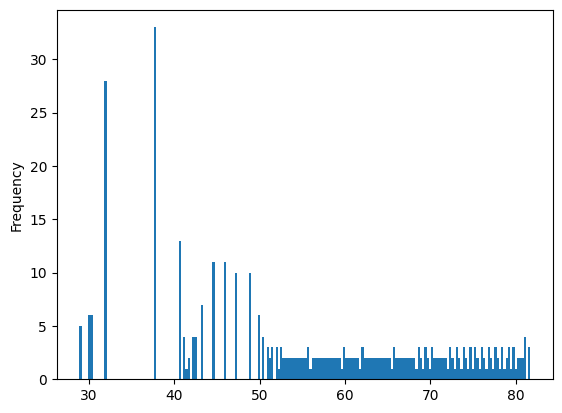

In [ ]:
# Generate 100 equally spaced Tm values between the min and max
min_tm = df['tm'].min()
max_tm = df['tm'].max()

sampled_tm_values = np.linspace(min_tm, max_tm, 400)

# Find the closest sample in the dataset for each sampled Tm value
sampled_data = []
for tm_value in sampled_tm_values:
    closest_row = df.iloc[(df['tm'] - tm_value).abs().argmin()]
    
    sampled_data.append(closest_row.to_frame().T)

sampled_df = pd.concat(sampled_data, ignore_index=True)
sampled_df.tm.plot.hist(bins=200)

##  Predict 3D Structures for Protein Sequences

In this step, the ESMFold API is used to predict the 3D structures of protein sequences. For each protein sequence in the dataset, a POST request is sent to the API, and the resulting protein structure in PDB format is saved to a file.

In [6]:
import requests
from tqdm import tqdm

# Define the API endpoint
api_url = "https://api.esmatlas.com/foldSequence/v1/pdb/"

def get_pdb(protein_sequence: str, fname: str):
    # Send the POST request with the protein sequence in the body
    response = requests.post(api_url, data=protein_sequence)

    # Check if the response is successful (status code 200)
    if response.status_code == 200:
        # Assuming the response contains the predicted protein structure in PDB format
        pdb_data = response.text
        
        # Save the PDB data to a file
        with open(f"{fname}.pdb", "w") as file:
            file.write(pdb_data)
        
        print(f"Protein structure saved as {fname}")
    else:
        print(f"Error {response.status_code}: {response.text}")


# # for i, row in df[df.tm==77.4].head(11).reset_index().iterrows():
# for i, row in df.head(50).reset_index().i§§terrows():
#     get_pdb(row.protein_sequence, f'data/predicted/low_tm_{row.tm}_{i}')


# for i, row in df.tail(50).reset_index().iterrows():
#     get_pdb(row.protein_sequence, f'data/predicted/high_tm_{row.tm}_{i}')

for i, row in tqdm(sampled_df.iloc[180:].reset_index().iterrows()):
    get_pdb(row.protein_sequence, f'data/predicted/tm_{row.tm}_{i+181}')

1it [00:00,  1.08it/s]

Protein structure saved as data/predicted/tm_52.8_181


2it [00:01,  1.23it/s]

Protein structure saved as data/predicted/tm_52.9_182


3it [00:02,  1.31it/s]

...

Protein structure saved as data/predicted/tm_81.7_398


219it [29:27,  1.39it/s]

Protein structure saved as data/predicted/tm_81.7_399


220it [29:27,  8.04s/it]

Protein structure saved as data/predicted/tm_81.7_400


In [7]:
257

257